In [294]:
import re
import pandas as pd
import numpy as np
import ast

import pandas as pd
from datetime import datetime


def parse_results(filepath):
    rows = []

    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split(",")

            if len(parts) < 7:
                continue

            dt = datetime.strptime(parts[0], "%a %b %d %H:%M:%S %Y")
            stim = parts[1].split("\\")[-1]
            correct = int(parts[3])

            nums = list(map(float, parts[4:]))

            if correct == 1:
                rt = nums[1]
            else:
                rt = nums[0]

            rows.append({
                "time": dt,
                "stim": stim,
                "correct": correct,
                "rt": rt
            })

    df = pd.DataFrame(rows).sort_values("time")
    df["engaged"] = df["rt"] < 9.9
    return df

def parse_perch(filepath):
    rows = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                time_str, state_str = line.split(",", 1)
                dt = datetime.strptime(time_str, "%a %b %d %H:%M:%S %Y")

                # state_str should look like "[1, 0, 0]"
                state = ast.literal_eval(state_str)

                if not isinstance(state, (list, tuple)) or len(state) != 3:
                    continue

                right, left, middle = map(int, state)

                rows.append({
                    "time": dt,
                    "right": right,
                    "left": left,
                    "middle": middle
                })

            except Exception:
                continue

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    return df.sort_values("time").reset_index(drop=True)


#df_results = parse_results("/Volumes/users/annietaylor/goNoGo2/einstein-20246611120Results.log")
#df_perch = parse_perch("/Volumes/users/annietaylor/goNoGo2/einstein-20246611120PerchHops.log")

# df_results = parse_results("/Volumes/users/annietaylor/goNoGo2/birdyeinstein-202464121433Results.log")
# df_perch = parse_perch("/Volumes/users/annietaylor/goNoGo2/birdyeinstein-202464121433PerchHops.log")

results_files = ["/Volumes/users/annietaylor/goNoGo2/birdygenius-2024638833Results.log",
                 "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereatingbug-2024638491Results.log",
               "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereating2bugs-202463124624Results.log",
               "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereatingbugs-202463131632Results.log",
                 "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereatingbugs-202463131632Results.log",
                 "/Volumes/users/annietaylor/goNoGo2/birdygenius-2024638833Results.log",
                 "/Volumes/users/annietaylor/goNoGo2/birdyeinstein-202464121433Results.log", 
                 "/Volumes/users/annietaylor/goNoGo2/einstein-20246611120Results.log",]
                #"/Volumes/users/annietaylor/goNoGo2/bard-20246711572Results.log"]

perch_files = ["/Volumes/users/annietaylor/goNoGo2/birdygenius-2024638833PerchHops.log",
               "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereatingbug-2024638491PerchHops.log",
               "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereating2bugs-202463124624PerchHops.log",
               "/Volumes/users/annietaylor/goNoGo2/birdygeniusaftereatingbugs-202463131632PerchHops.log",
               "/Volumes/users/annietaylor/goNoGo2/birdygenius-2024638833PerchHops.log",
               "/Volumes/users/annietaylor/goNoGo2/birdyeinstein-202464121433PerchHops.log",
              "/Volumes/users/annietaylor/goNoGo2/einstein-20246611120PerchHops.log",]
               #"/Volumes/users/annietaylor/goNoGo2/bard-20246711572PerchHops.log"]

In [295]:
# from pathlib import Path
# import pandas as pd

# root = Path("/Volumes/users/annietaylor/goNoGo2")

# def file_kind(name):
#     if name.endswith("Results.log"):
#         return "results"
#     if name.endswith("PerchHops.log"):
#         return "perch"
#     if name.endswith("Params.log"):
#         return "params"
#     return None

# def session_stem(name):
#     for suffix in ("Results.log", "PerchHops.log", "Params.log"):
#         if name.endswith(suffix):
#             return name[:-len(suffix)]
#     return None

# # Build a manifest of all session files
# manifest = []
# for p in root.iterdir():
#     if not p.is_file():
#         continue
#     kind = file_kind(p.name)
#     stem = session_stem(p.name)
#     if kind and stem:
#         manifest.append({"session": stem, "kind": kind, "path": str(p)})

# manifest = pd.DataFrame(manifest)

# # Optional: exclude obvious debugging/test sessions
# exclude_prefixes = (
#     "test", "tests", "testc", "testingagain",
#     "nobird", "nobd", "t-", "qall"
# )
# manifest = manifest[~manifest["session"].str.startswith(exclude_prefixes)].copy()

# # Keep only sessions that have both results and perch logs
# valid_sessions = (
#     manifest.groupby("session")["kind"]
#     .nunique()
# )
# valid_sessions = valid_sessions[valid_sessions >= 2].index
# manifest = manifest[manifest["session"].isin(valid_sessions)].copy()

# results_dfs = []
# perch_dfs = []

# for session, g in manifest.groupby("session"):
#     res = g[g["kind"] == "results"]["path"]
#     per = g[g["kind"] == "perch"]["path"]

#     if len(res) != 1 or len(per) != 1:
#         continue

#     df_r = parse_results(res.iloc[0])
#     df_p = parse_perch(per.iloc[0])

#     df_r["session"] = session
#     df_p["session"] = session

#     results_dfs.append(df_r)
#     perch_dfs.append(df_p)


# df_results_all = pd.concat(results_dfs, ignore_index=True).sort_values(["session", "time"])
# df_perch_all = pd.concat(perch_dfs, ignore_index=True).sort_values(["session", "time"])

In [296]:
import os
import pandas as pd

def load_multiple(results_files, perch_files):
    results_list = []
    perch_list = []

    for i, path in enumerate(results_files):
        df = parse_results(path)

        session_name = os.path.basename(path).replace("Results.log", "")

        df["session"] = session_name
        df["session_idx"] = i

        results_list.append(df)

    for i, path in enumerate(perch_files):
        df = parse_perch(path)

        session_name = os.path.basename(path).replace("PerchHops.log", "")

        df["session"] = session_name
        df["session_idx"] = i

        perch_list.append(df)

    df_results_all = pd.concat(results_list, ignore_index=True)
    df_perch_all = pd.concat(perch_list, ignore_index=True)

    # Sort globally
    df_results_all = df_results_all.sort_values("time").reset_index(drop=True)
    df_perch_all = df_perch_all.sort_values("time").reset_index(drop=True)

    return df_results_all, df_perch_all


df_results_all, df_perch_all = load_multiple(results_files, perch_files)

In [297]:
import pandas as pd
import numpy as np

# Ensure sorted
df_results_all = df_results_all.sort_values("time").reset_index(drop=True)
df_perch_all = df_perch_all.sort_values("time").reset_index(drop=True)

# Engagement (timeout threshold from your task)
df_results_all["engaged"] = df_results_all["rt"] < 9.9

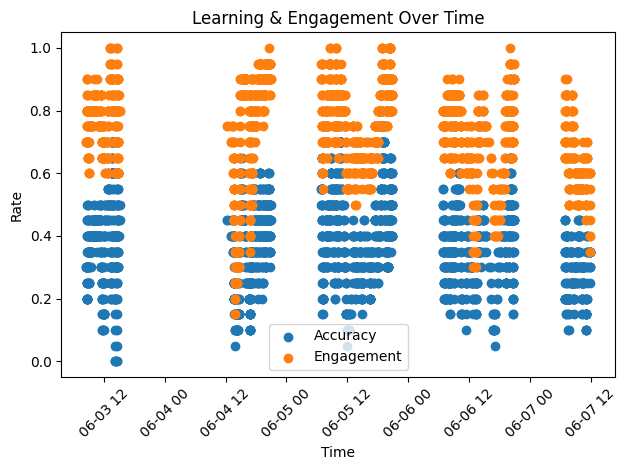

In [298]:
import matplotlib.pyplot as plt

window = 20

df_results_all["rolling_acc"] = df_results_all["correct"].rolling(window).mean()
df_results_all["rolling_eng"] = df_results_all["engaged"].rolling(window).mean()

plt.figure()
plt.scatter(df_results_all["time"], df_results_all["rolling_acc"], label="Accuracy")
plt.scatter(df_results_all["time"], df_results_all["rolling_eng"], label="Engagement")
plt.xlabel("Time")
plt.ylabel("Rate")
plt.title("Learning & Engagement Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

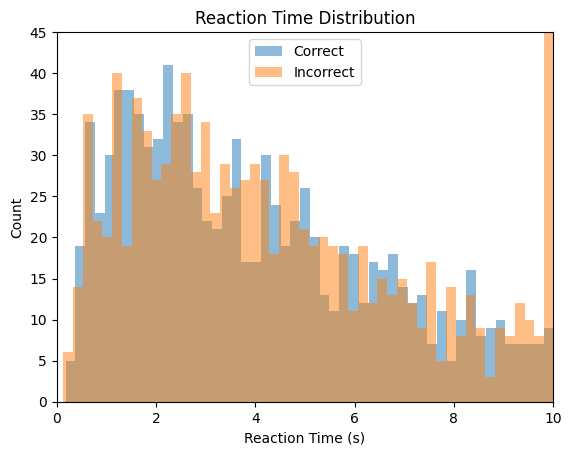

In [329]:
plt.figure()
plt.hist(df_results_all[df_results_all["correct"] == 1]["rt"], bins=50, alpha=0.5, label="Correct")
plt.hist(df_results_all[df_results_all["correct"] == 0]["rt"], bins=50, alpha=0.5, label="Incorrect")
plt.xlabel("Reaction Time (s)")
plt.ylabel("Count")
plt.xlim(0,10)
plt.ylim(0,45)
plt.title("Reaction Time Distribution")
plt.legend()
plt.show()

In [300]:
stim_perf = df_results_all.groupby("stim")["correct"].mean()

print("\nAccuracy by stimulus:")
print(stim_perf)


Accuracy by stimulus:
stim
seq1_iab_cde.wav    0.392245
seq4_iab_lmn.wav    0.355662
Name: correct, dtype: float64


In [301]:
df_perch["choice"] = None

df_perch_all.loc[df_perch_all["right"] == 1, "choice"] = "right"
df_perch_all.loc[df_perch_all["left"] == 1, "choice"] = "left"
df_perch_all.loc[df_perch_all["middle"] == 1, "choice"] = "middle"

# Only keep changes
df_perch_all["change"] = df_perch_all["choice"].ne(df_perch_all["choice"].shift())

events = df_perch_all[df_perch_all["change"] & df_perch_all["choice"].notna()].copy()

In [302]:
def assign_choices(trials, events):
    choices = []

    for _, trial in trials.iterrows():
        t = trial["time"]

        future = events[events["time"] >= t]

        if len(future) == 0:
            choices.append(None)
        else:
            choices.append(future.iloc[0]["choice"])

    trials["choice"] = choices
    return trials

df_results_all = assign_choices(df_results_all, events)

In [303]:
choice_dist = df_results_all["choice"].value_counts(normalize=True)

print("\nChoice distribution:")
print(choice_dist)


Choice distribution:
choice
middle    0.950289
left      0.029672
right     0.020039
Name: proportion, dtype: float64


In [304]:
def compute_latency(trials, events):
    latencies = []

    for _, trial in trials.iterrows():
        t = trial["time"]

        future = events[events["time"] >= t]

        if len(future) == 0:
            latencies.append(np.nan)
        else:
            latencies.append((future.iloc[0]["time"] - t).total_seconds())

    trials["latency_from_perch"] = latencies
    return trials

df_results_all = compute_latency(df_results_all, events)

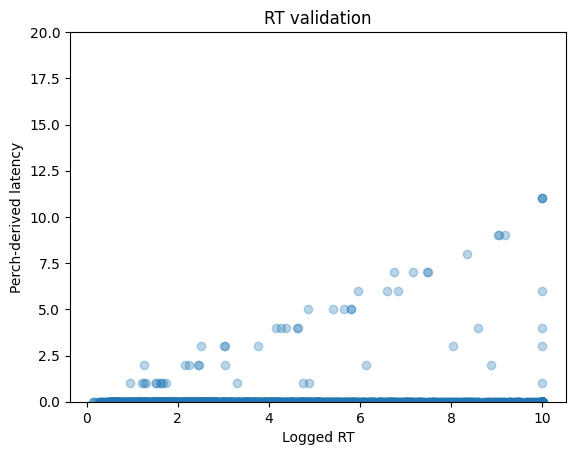

In [305]:
plt.figure()
plt.scatter(df_results_all["rt"], df_results_all["latency_from_perch"], alpha=0.3)
plt.xlabel("Logged RT")
plt.ylabel("Perch-derived latency")
plt.ylim(0,20)
plt.title("RT validation")
plt.show()

In [306]:
def detect_premature(trials, events):
    prem = []

    for _, trial in trials.iterrows():
        t = trial["time"]

        before = events[
            (events["time"] < t) &
            (events["time"] > t - pd.Timedelta(seconds=2))
        ]

        prem.append(len(before) > 0)

    trials["premature"] = prem
    return trials

df_results_all = detect_premature(df_results_all, events)

In [307]:
print("\nPremature response rate:", df_results_all["premature"].mean())


Premature response rate: 0.18689788053949905


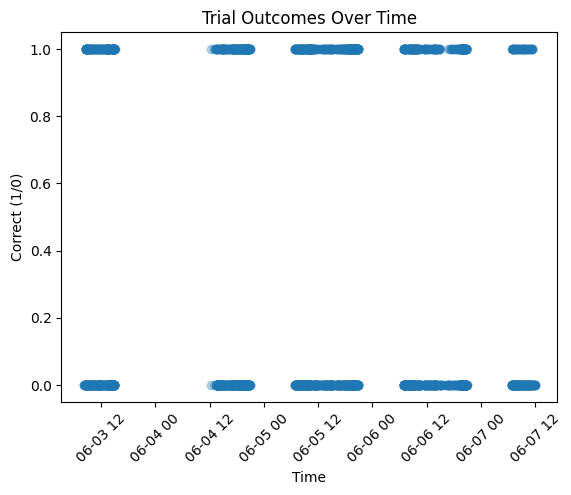

In [308]:
plt.figure()
plt.scatter(df_results_all["time"], df_results_all["correct"], alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Correct (1/0)")
plt.title("Trial Outcomes Over Time")
plt.xticks(rotation=45)
plt.show()

In [309]:
df_results_all.groupby("session")["correct"].mean()

session
birdyeinstein-202464121433                  0.386624
birdygenius-2024638833                      0.307692
birdygeniusaftereating2bugs-202463124624    0.400000
birdygeniusaftereatingbug-2024638491        0.365482
birdygeniusaftereatingbugs-202463131632     0.423913
einstein-20246611120                        0.332740
Name: correct, dtype: float64

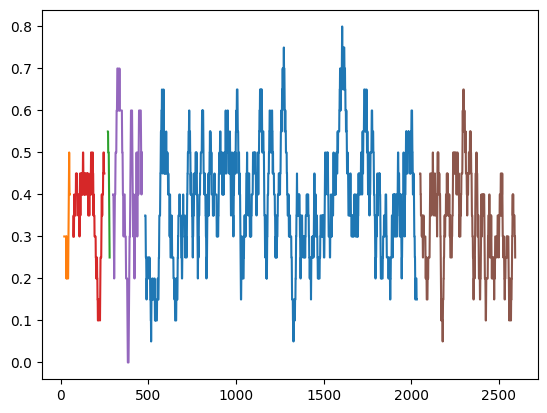

In [330]:
for s, df_s in df_results_all.groupby("session"):
    plt.plot(df_s["correct"].rolling(20).mean(), label=s)

#plt.legend()

In [311]:
df_results_all.groupby("session_idx")["correct"].mean()

session_idx
0    0.307692
1    0.365482
2    0.400000
3    0.423913
4    0.423913
5    0.307692
6    0.386624
7    0.332740
Name: correct, dtype: float64

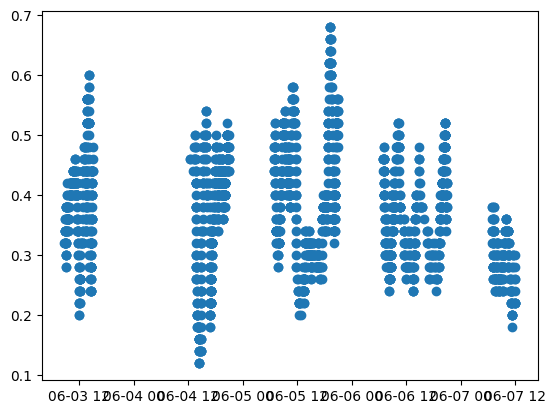

In [312]:
plt.scatter(df_results_all["time"], df_results_all["correct"].rolling(50).mean())

Text(0, 0.5, 'Accuracy')

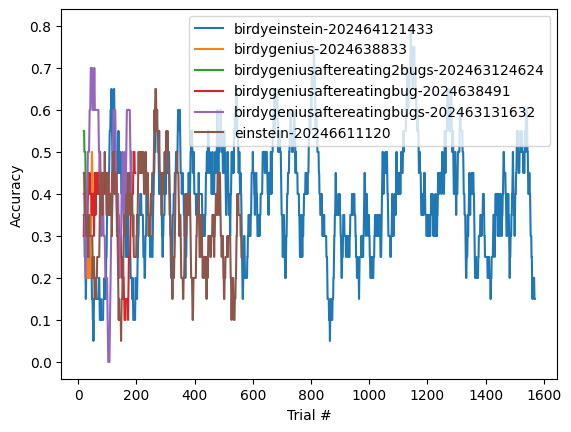

In [313]:
df_results_all["trial_in_session"] = df_results_all.groupby("session").cumcount()

plt.figure()
for s, df_s in df_results_all.groupby("session"):
    plt.plot(df_s["trial_in_session"], df_s["correct"].rolling(20).mean(), label=s)

plt.legend()
plt.xlabel("Trial #")
plt.ylabel("Accuracy")

In [314]:
import statsmodels.formula.api as smf

df = df_results_all.copy()

# keep only valid choice trials
df = df[df["choice"].isin(["left", "right"])]

# encode
df["choice_bin"] = (df["choice"] == "right").astype(int)
df["stim_bin"] = (df["stim"] == df["stim"].unique()[0]).astype(int)

model = smf.logit("choice_bin ~ stim_bin", data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.674157
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             choice_bin   No. Observations:                  129
Model:                          Logit   Df Residuals:                      127
Method:                           MLE   Df Model:                            1
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:               0.0001370
Time:                        11:49:30   Log-Likelihood:                -86.966
converged:                       True   LL-Null:                       -86.978
Covariance Type:            nonrobust   LLR p-value:                    0.8773
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4169      0.239     -1.743      0.081      -0.886       0.052
stim_bin       0.0559      0.

In [315]:
import numpy as np
import statsmodels.formula.api as smf

df = df.copy()

# keep only valid choice trials
df = df[df["choice"].isin(["left", "right"])].copy()

# drop rows where lagged values don't exist
df["prev_choice"] = df["choice"].shift(1)
df["prev_correct"] = df["correct"].shift(1)

df = df.dropna(subset=["prev_choice", "prev_correct", "stim"])

# encode binary variables
df["choice_bin"] = (df["choice"] == "right").astype(int)
df["prev_choice_bin"] = (df["prev_choice"] == "right").astype(int)
df["stay"] = (df["choice_bin"] == df["prev_choice_bin"]).astype(int)

# pick one stimulus as reference
df["stim_bin"] = (df["stim"] == df["stim"].unique()[0]).astype(int)

model = smf.logit("choice_bin ~ stim_bin + prev_correct + stay", data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.654299
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             choice_bin   No. Observations:                  128
Model:                          Logit   Df Residuals:                      124
Method:                           MLE   Df Model:                            3
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                 0.03133
Time:                        11:49:30   Log-Likelihood:                -83.750
converged:                       True   LL-Null:                       -86.459
Covariance Type:            nonrobust   LLR p-value:                    0.1436
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0859      0.362     -0.238      0.812      -0.794       0.623
stim_bin         0.0314

In [316]:
# define "go right" as signal
df["hit"] = (df["stim"] == "stim_right") & (df["choice"] == "right")
df["false_alarm"] = (df["stim"] == "stim_left") & (df["choice"] == "right")

In [317]:
df_eng = df[df["engaged"]]
df_eng["correct"].mean()

np.float64(0.4909090909090909)

In [318]:
df["engaged"].mean()

np.float64(0.859375)

In [319]:
df["responded"] = df["rt"] < 9.9

In [320]:
df["engaged_block"] = (df["engaged"].rolling(10).mean() > 0.5)

In [321]:
df[df["engaged_block"]].groupby("stim")["correct"].mean()

stim
seq1_iab_cde.wav    0.402985
seq4_iab_lmn.wav    0.442308
Name: correct, dtype: float64

In [322]:
df_results_all.groupby("session")["correct"].mean()

session
birdyeinstein-202464121433                  0.386624
birdygenius-2024638833                      0.307692
birdygeniusaftereating2bugs-202463124624    0.400000
birdygeniusaftereatingbug-2024638491        0.365482
birdygeniusaftereatingbugs-202463131632     0.423913
einstein-20246611120                        0.332740
Name: correct, dtype: float64

In [323]:
pd.crosstab(df["stim"], df["choice"], normalize="index")

choice,left,right
stim,,
seq1_iab_cde.wav,0.602740,0.397260
seq4_iab_lmn.wav,0.581818,0.418182


In [324]:
df_results["premature"].mean()

np.float64(0.14968152866242038)

In [325]:
df_results.groupby("premature")["correct"].mean()

premature
False    0.373034
True     0.463830
Name: correct, dtype: float64

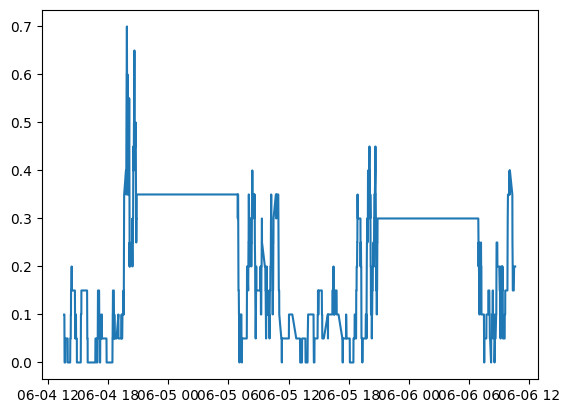

In [326]:
df_results["premature_roll"] = df_results["premature"].rolling(20).mean()

plt.plot(df_results["time"], df_results["premature_roll"])

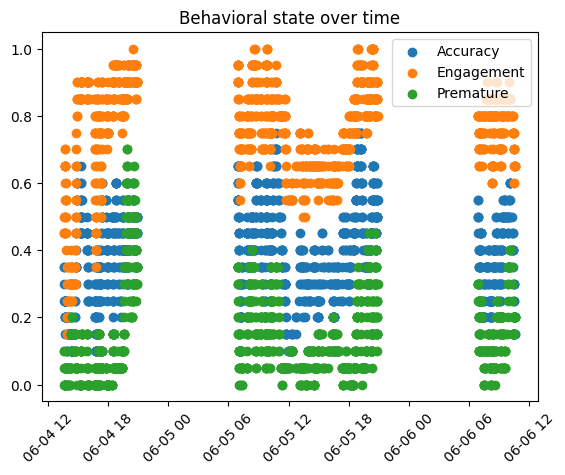

In [327]:
plt.figure()

plt.scatter(df_results["time"], df_results["rolling_acc"], label="Accuracy")
plt.scatter(df_results["time"], df_results["rolling_eng"], label="Engagement")
plt.scatter(df_results["time"], df_results["premature_roll"], label="Premature")

plt.legend()
plt.xticks(rotation=45)
plt.title("Behavioral state over time")
plt.show()

In [328]:
os.listdir("/Volumes/users/annietaylor/goNoGo2/")

['birdysmort-202452981933Params.log',
 't-2024610103624Results.log',
 'birdsmrt-202452915113PerchHops.log',
 'cdef-202461411814PerchHops.log',
 'playbackopts-202453110201Results.log',
 'test-2024531164747Results.log',
 'test-2024528144859PerchHops.log',
 'test-2024611112426PerchHops.log',
 'tests-2024528142733Results.log',
 'testc-2024531165523PerchHops.log',
 'birdygeniusaftereatingbugs-202463131632Params.log',
 'humandumb-20245298272Params.log',
 'birdygeniusaftereating2bugs-202463124624Params.log',
 'nobird-2024528142139Results.log',
 'test-202453117819Params.log',
 'test-202461010354Params.log',
 'smrt-2024529165956Params.log',
 'birdsmrt-202452915113Results.log',
 't-202461010377Results.log',
 'nobd-2024528142657PerchHops.log',
 't-2024531162357Results.log',
 'tests-2024528142733Params.log',
 'test-2024531162511PerchHops.log',
 'birdygifted2-2024530102826Params.log',
 'birdygifted-202453073327PerchHops.log',
 'birdsmrt-202452915113Params.log',
 'test-202461010354PerchHops.log',
 '